In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read data understand from user which column is for ds and y
# understand the intervals
df = pd.read_csv("demand_supply_forecast_2W.csv")
df.head()

,create_event_timestamp,jakarta_label_minute_timestamp,jkt_date,day_of_week,jakarta_order_hour,service_type_group,service_area_id,pickup_s2id_10,pickup_s2id_11,pickup_s2id_12,pickup_s2id_13,demand_next_15m
0,2026-05-06 08:00:00,2026-05-06 08:00:00,2026-05-06,4,0,2W,75,3194913608991506432,3194913334113599488,3194913127955169280,3194913145135038464,0
1,2026-05-06 08:00:00,2026-05-06 08:01:00,2026-05-06,4,0,2W,75,3194913608991506432,3194913334113599488,3194913127955169280,3194913145135038464,0
2,2026-05-06 08:00:00,2026-05-06 08:02:00,2026-05-06,4,0,2W,75,3194913608991506432,3194913334113599488,3194913127955169280,3194913145135038464,0
3,2026-05-06 08:00:00,2026-05-06 08:03:00,2026-05-06,4,0,2W,75,3194913608991506432,3194913334113599488,3194913127955169280,3194913145135038464,0
4,2026-05-06 08:00:00,2026-05-06 08:04:00,2026-05-06,4,0,2W,75,3194913608991506432,3194913334113599488,3194913127955169280,3194913145135038464,0


In [7]:
df['jakarta_label_minute_timestamp'] = pd.to_datetime(df['jakarta_label_minute_timestamp'])

ds_col = 'jakarta_label_minute_timestamp'
y_col = 'demand_next_15m'

(4320, 12)


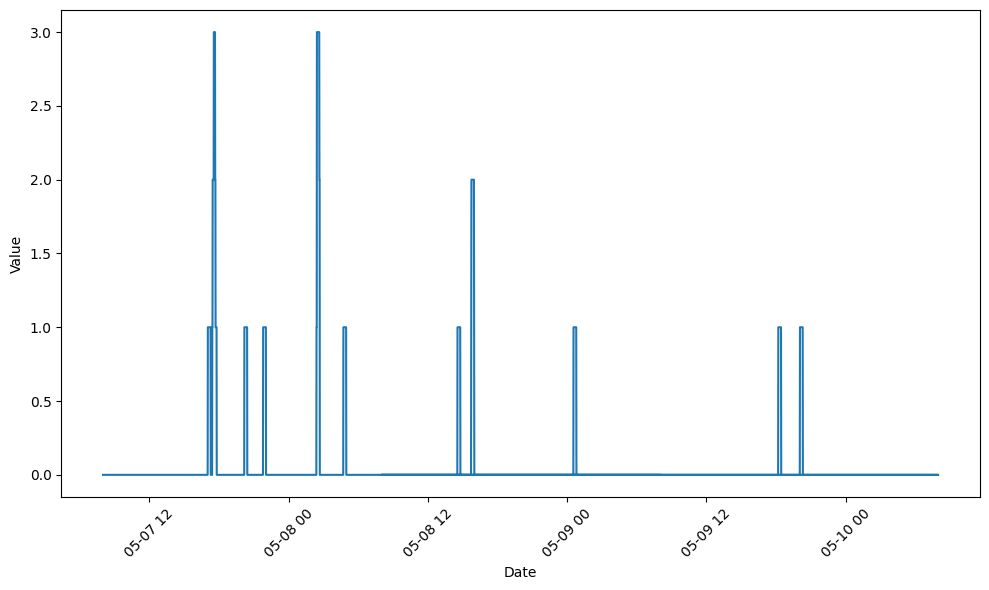

In [14]:
# plot and save the graph, idenfiy is there any seasonal factors
df_sub = df[df['jkt_date'].isin(["2026-05-07", "2026-05-08", "2026-05-09"])]
print(df_sub.shape)

plt.figure(figsize=(10, 6))
plt.plot(df_sub[ds_col], df_sub[y_col])

plt.xlabel('Date')
plt.ylabel('Value')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Modelling

In [19]:
df.rename(columns={ds_col: "ds", y_col: "y"}, inplace=True)

In [36]:
# base on the findings do cross val and performance validation
# infer seasonality
# add custom seasonality if it makes sense
# ask for holidays/special events if the span if greater than a year
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

# properly arrange to have less than 10 folds
m = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=True)
m.fit(df)
df_cv = cross_validation(m, initial='20000 minute', period='6000 minute', horizon='3000 minute')
df_cv.head()

16:54:31 - cmdstanpy - INFO - Chain [1] start processing
16:54:33 - cmdstanpy - INFO - Chain [1] done processing
 88%|██████████████████████████████████████████████████▎      | 15/17 [01:37<00:13,  6.53s/it]

  0%|                                                                   | 0/4 [00:00<?, ?it/s]16:54:34 - cmdstanpy - INFO - Chain [1] start processing
16:54:36 - cmdstanpy - INFO - Chain [1] done processing

 25%|██████████████▊                                            | 1/4 [00:02<00:07,  2.59s/it]16:54:36 - cmdstanpy - INFO - Chain [1] start processing
16:54:38 - cmdstanpy - INFO - Chain [1] done processing

 50%|█████████████████████████████▌                             | 2/4 [00:05<00:05,  2.73s/it]16:54:39 - cmdstanpy - INFO - Chain [1] start processing
16:54:41 - cmdstanpy - INFO - Chain [1] done processing

 75%|████████████████████████████████████████████▎              | 3/4 [00:08<00:02,  2.82s/it]16:54:42 - cmdstanpy - INFO - Chain [1] start processing
16:54:44 - cmdst

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2026-04-28 06:20:00,-0.063184,-0.381172,0.234034,0,2026-04-28 06:19:00
1,2026-04-28 06:21:00,-0.062954,-0.376430,0.237034,0,2026-04-28 06:19:00
2,2026-04-28 06:22:00,-0.062720,-0.366045,0.241606,0,2026-04-28 06:19:00
3,2026-04-28 06:23:00,-0.062481,-0.377744,0.222539,0,2026-04-28 06:19:00
4,2026-04-28 06:24:00,-0.062238,-0.374419,0.227900,0,2026-04-28 06:19:00


In [46]:
# calculate perfomance metrics 
df_cv['abs_error'] = (df_cv['y'] - df_cv['yhat']).abs()

# Calculate sMAPE component for each row
# Formula: |y - yhat| / ((|y| + |yhat|) / 2) * 100
# We use a small epsilon or np.where to handle cases where both y and yhat are zero
denominator = (df_cv['y'].abs() + df_cv['yhat'].abs()) / 2
df_cv['smape_comp'] = np.where(denominator == 0, 0, (df_cv['abs_error'] / denominator))

# Group by cutoff and aggregate
cutoff_metrics = df_cv.groupby('cutoff').agg(
    mae=('abs_error', 'mean'),
    smape=('smape_comp', 'mean')
).reset_index()

cutoff_metrics

,cutoff,mae,smape
0,2026-04-28 06:19:00,0.130396,2.000000
1,2026-05-02 10:19:00,0.079580,1.994165
2,2026-05-06 14:19:00,0.214931,1.972644
3,2026-05-10 18:19:00,0.097458,1.995753


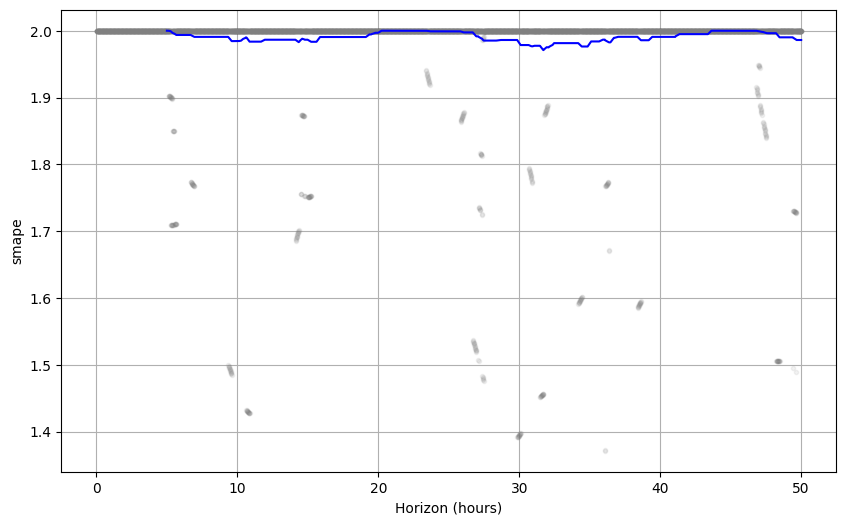

In [47]:
# save performance plots mae and smape
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='smape')